In [34]:
import re
import requests
import string
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from collections import Counter, defaultdict
import tiktoken
import gensim.downloader as api

In [3]:
glove = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


In [13]:
key_words = glove.key_to_index.keys()
print(f"The dictionary contains {len(key_words)} items")
list(key_words)[:13] # this is not a tokenizer, just a list of words for which the embeddings vectors have been calculated 

The dictionary contains 400000 items


['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s", 'for', '-', 'that']

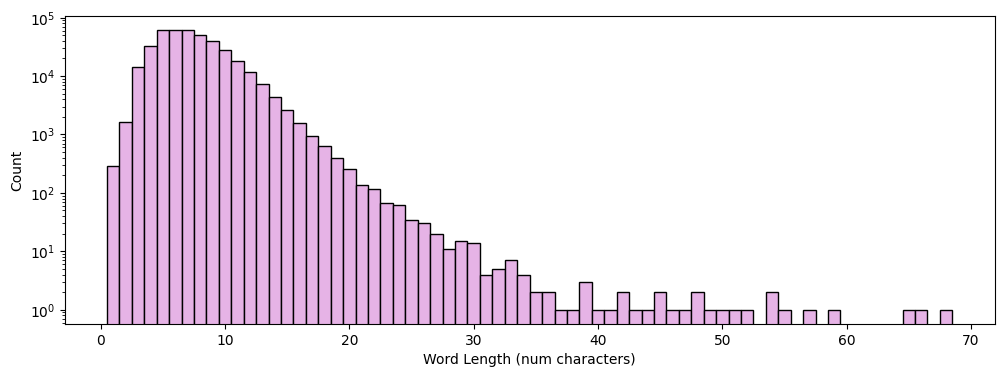

In [ ]:
# distribution of token character lengths
token_lengths = np.zeros(len(key_words), dtype=int)
for idx, word in enumerate(key_words):
    token_lengths[idx] = len(word)
    
uniq_vals, uniq_counts = np.unique(token_lengths, return_counts=True)

plt.figure(figsize=(12, 4))
plt.bar(uniq_vals, uniq_counts, width=uniq_vals[1] - uniq_vals[0], facecolor=[0.9, 0.7, 0.9], edgecolor="black")
plt.gca().set(xlabel="Word Length (num characters)", ylabel="Count")
plt.yscale("log")
plt.show()
# top counts are for lengts 5, 6 and 7 characters

In [31]:
print(f"The embeddings matrix is {glove.vectors.shape}")

print(f"The world apple has index #{glove.get_index("apple")}")

# print(f"The world apple has index #{glove.get_index("asdfqwer")}") it wont work since it is not a tokenizer, it transforms real words into embedded dimensions

The embeddings matrix is (400000, 50)
The world apple has index #3292


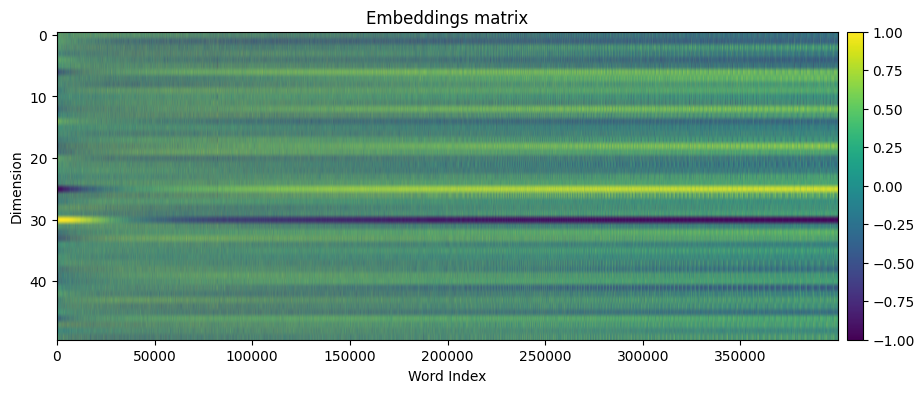

In [32]:
plt.figure(figsize=(12, 4))
plt.imshow(glove.vectors.T, vmin=-1, vmax=1, aspect="auto")
plt.gca().set(xlabel="Word Index", ylabel="Dimension", title="Embeddings matrix")
plt.colorbar(pad=0.01)
plt.show()

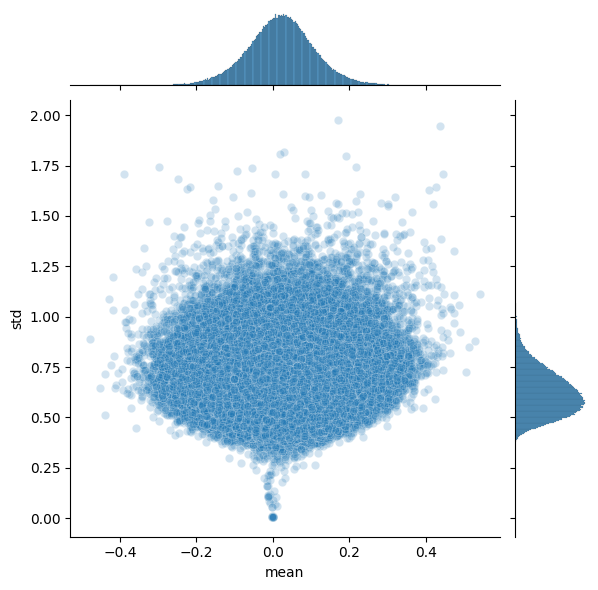

In [ ]:
# mean and std across each embeddig dim --> how far from the origin of this embedding space is this one individual word
emb_mean = glove.vectors.mean(axis=1)
emb_std = glove.vectors.std(axis=1)

df = pd.DataFrame(np.vstack((emb_mean, emb_std)).T, columns=["mean", "std"])

sns.jointplot(x="mean", y="std", data=df, alpha=0.2)
plt.show()

# slightly bias towards possitive means
# some points have a low std (<0.25), may be very obscure words or character sequences that appear very infrequently.

In [ ]:
# words with low std, meaning very very tiny projection, they are close to the origin.
for ind in df[df["std"] < 0.25].index:
    print(glove.index_to_key[ind])

lastly
bb96
kd96
js03
15utl
k977-1
kd95
kd94
bb94
rw95
naborsind
dellcptr
http://www.mediabynumbers.com
ooooooooooooooooooooooooooooooooooooooo
em96
kd97
str95bb
devonengy
bulletinyyy
oly-2004-cycling
bdb94
bb97
oly-2004-tennis
gph04bb
www.slarmy.org
k587-1
mo95
65stk
piyanart
srivalo
js94bb
js04bb
k978-1
24aou94
27aou94
28aou94
oly-2004-fhockey
oly-2004-gymnastics
greg.wilcoxdailynews.com
mo94
str94
http://www.opel.com


In [57]:
# pick a word
word = "banana"

# get its index in the embedding
word_idx = glove.get_index(word)

# get the embedding vector
word_vector = glove.vectors[word_idx, :]

print(word_vector)

# or even easier
print(glove[word])

[-0.25522  -0.75249  -0.86655   1.1197    0.12887   1.0121   -0.57249
 -0.36224   0.44341  -0.12211   0.073524  0.21387   0.96744  -0.068611
  0.51452  -0.053425 -0.21966   0.23012   1.043    -0.77016  -0.16753
 -1.0952    0.24837   0.20019  -0.40866  -0.48037   0.10674   0.5316
  1.111    -0.19322   1.4768   -0.51783  -0.79569   1.7971   -0.33392
 -0.14545  -1.5454    0.0135    0.10684  -0.30722  -0.54572   0.38938
  0.24659  -0.85166   0.54966   0.82679  -0.68081  -0.77864  -0.028242
 -0.82872 ]
[-0.25522  -0.75249  -0.86655   1.1197    0.12887   1.0121   -0.57249
 -0.36224   0.44341  -0.12211   0.073524  0.21387   0.96744  -0.068611
  0.51452  -0.053425 -0.21966   0.23012   1.043    -0.77016  -0.16753
 -1.0952    0.24837   0.20019  -0.40866  -0.48037   0.10674   0.5316
  1.111    -0.19322   1.4768   -0.51783  -0.79569   1.7971   -0.33392
 -0.14545  -1.5454    0.0135    0.10684  -0.30722  -0.54572   0.38938
  0.24659  -0.85166   0.54966   0.82679  -0.68081  -0.77864  -0.028242
 -0.82

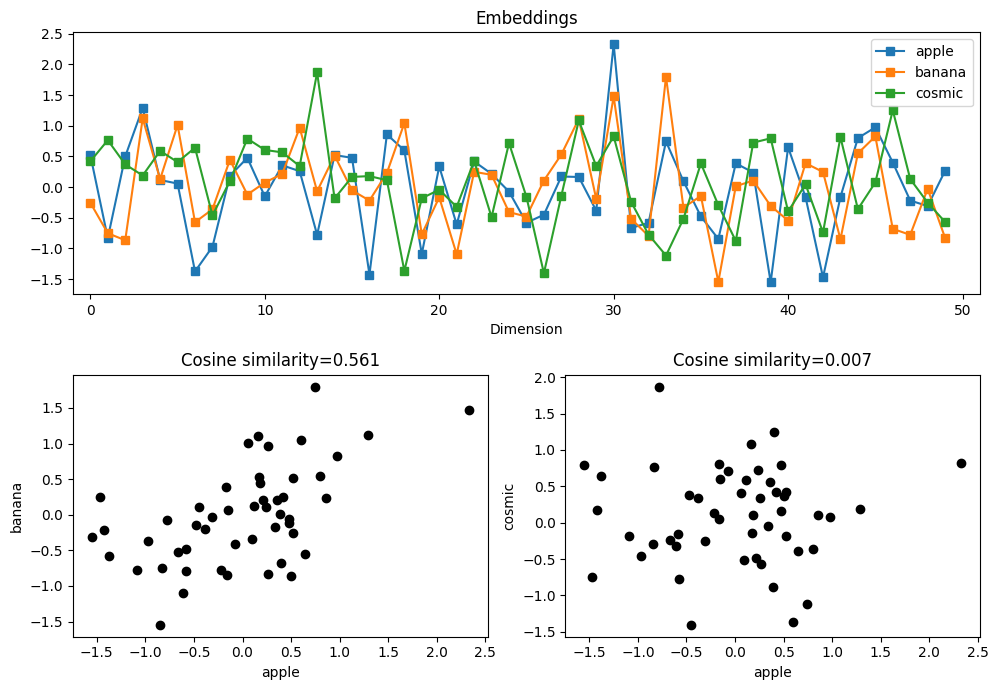

In [ ]:
# relationships across embedding vectors
word1 = "apple"
word2 = "banana"
word3 = "cosmic"

fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 2)
ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])

for idx, word in enumerate([word1, word2, word3]):
    ax0.plot(glove[word], "s-", label=word)
    
ax0.set(xlabel="Dimension", title="Embeddings", xlim=[-1, glove.vectors.shape[1]+1])
ax0.legend()

# plot the embeddings by each other
cos_sim12 = glove.similarity(word1, word2)
ax1.plot(glove[word1], glove[word2], "ko")
ax1.set(xlabel=word1, ylabel=word2, title=f"Cosine similarity={cos_sim12:.3f}")

cos_sim13 = glove.similarity(word1, word3)
ax2.plot(glove[word1], glove[word3], "ko")
ax2.set(xlabel=word1, ylabel=word3, title=f"Cosine similarity={cos_sim13:.3f}")

plt.tight_layout()
plt.show()

# in the first plot we can see that banana an apple are closer and they go up and down approximately in the same way

# banana and apple have a cos similarity higher than 0.5, which means a high relationship

In [74]:
# methods to identify similar and dissimilar words
glove.most_similar("banana", topn=8)

[('bananas', 0.8152028322219849),
 ('coconut', 0.7872511148452759),
 ('pineapple', 0.7579814791679382),
 ('mango', 0.7556402087211609),
 ('beet', 0.7212650179862976),
 ('fruit', 0.7181406021118164),
 ('sugar', 0.7180197834968567),
 ('growers', 0.7165752649307251)]

In [ ]:
glove.doesnt_match(["banana", "banana", "pirate", "mango"]) # which one has the worst match respect to the others

'pirate'

In [ ]:
glove.most_similar(["banana", "banana", "pirate", "mango"], topn=1) # the most similar word to this group, it could change if we change pirate for color for example

[('fruit', 0.8350610733032227)]